In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"titanic.csv"
file_path = os.path.join(base_path,file_name)

In [3]:
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [4]:
drop_columns = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked"]
titanic_df = df.drop(drop_columns, axis=1)

In [5]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## 1단계, 데이터 전처리

In [6]:
# 수치형: Age, SipSp, Parch, Fare
# 분류형: Survived, Pclass, Sex
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [7]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


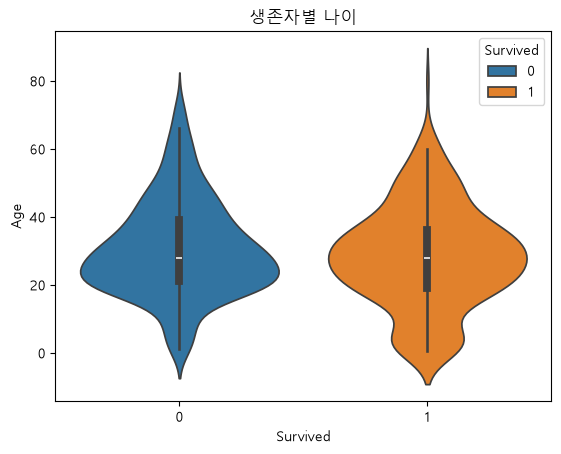

In [8]:
sns.violinplot(titanic_df, x="Survived", y="Age", hue="Survived")
plt.title("생존자별 나이")
plt.show()

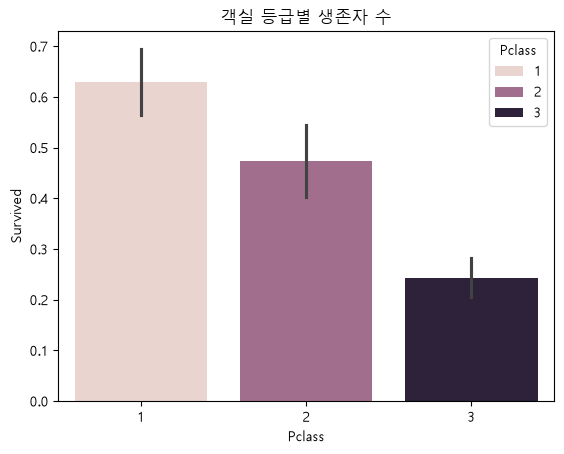

In [9]:
sns.barplot(titanic_df, x="Pclass", y="Survived", hue="Pclass")
plt.title("객실 등급별 생존자 수")
plt.show()

In [10]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

In [11]:
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


## 원 핫 인코딩(One-Hot encoding)
- 글자나 범주형(분류형) 데이터를 컴퓨터가 좋아하는 0과 1의 행렬구조로 변환하는 전처리 기술이다.

In [12]:
# 두 방법 다 사용해도 ㄱㅊ

# titanic_df["Sex"].map(lambda gender: {"male":0, "female":1}[gender])
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22,1,0,7.2500
1,1,1,1,38,1,0,71.2833
2,1,3,1,26,0,0,7.9250
3,1,1,1,35,1,0,53.1000
4,0,3,0,35,0,0,8.0500


## 파생변수

In [13]:
# 동승자 수 구하기.  형제+부모자식+나
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22,1,0,7.2500,2
1,1,1,1,38,1,0,71.2833,2
2,1,3,1,26,0,0,7.9250,1
3,1,1,1,35,1,0,53.1000,2
4,0,3,0,35,0,0,8.0500,1


### 상관관계 분석 및 다중공선성

In [17]:
# 상관관계 확인 표
corr_matrix = titanic_df.corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,0.543351,-0.064909,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.131900,-0.339999,0.083081,0.018443,-0.549500,0.065997
Sex,0.543351,-0.131900,1.000000,-0.080750,0.114631,0.245489,0.182333,0.200988
Age,-0.064909,-0.339999,-0.080750,1.000000,-0.233066,-0.172745,0.096838,-0.245593
SibSp,-0.035322,0.083081,0.114631,-0.233066,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,0.245489,-0.172745,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.182333,0.096838,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,0.200988,-0.245593,0.890712,0.783111,0.217138,1.000000


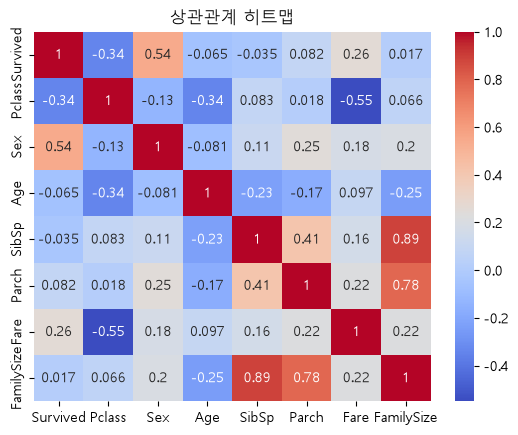

In [21]:
# 상관관계 시각화
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [25]:
# 데이터 분할
X = titanic_df.drop("Survived", axis=1)
X.head()
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [26]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize'], dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_18712\602452674.py:1: UserWarning: The design matrix is poorly conditioned (condition number=3.13e+15). VIF calculations may be numerically unstable.
  vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
C:\anaconda3\envs\machine_learning\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\anaconda3\envs\machine_learning\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\anaconda3\envs\machine_learning\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti)

[np.float64(1.679480657151526),
 np.float64(1.0999293570782829),
 np.float64(1.2110080956064615),
 np.float64(1000799917193443.5),
 np.float64(1000799917193443.5),
 np.float64(1.5928864776687566),
 np.float64(1000799917193443.5)]

### VIF
- 한 독립변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지 설명하는 값을 의미한다.
  즉 독립변수와 독립변수와의 관계를 의미하며, 다른 변수들과의 조합을 수치로 표현한 것이다.

### VIF 해석
- VIF < 5 : 문제 없음
- 5 <= VIF <= 10: 주의
- VIF > 10: 다중 공선성 의심(조치, 삭제, 고려)

In [27]:
titanic_df = titanic_df.drop(["SibSp", "Parch"], axis=1)
titanic_df

,Survived,Pclass,Sex,Age,Fare,FamilySize
0,0,3,0,22,7.2500,2
1,1,1,1,38,71.2833,2
2,1,3,1,26,7.9250,1
3,1,1,1,35,53.1000,2
4,0,3,0,35,8.0500,1
...,...,...,...,...,...,...
886,0,2,0,27,13.0000,1
887,1,1,1,19,30.0000,1
888,0,3,1,28,23.4500,4
889,1,1,0,26,30.0000,1


In [28]:
X = titanic_df.drop("Survived", axis=1)
print(X.head())
y = titanic_df["Survived"]
print(y.head())

   Pclass  Sex  Age     Fare  FamilySize
0       3    0   22   7.2500           2
1       1    1   38  71.2833           2
2       3    1   26   7.9250           1
3       1    1   35  53.1000           2
4       3    0   35   8.0500           1
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [29]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

Index(['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize'], dtype='str')


[np.float64(1.679362715497996),
 np.float64(1.0792936783037335),
 np.float64(1.2098971414514443),
 np.float64(1.589377177831002),
 np.float64(1.190725366150555)]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 5) (179, 5) (712,) (179,)


In [31]:
scaler = StandardScaler()

#표준화
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression

## 2단계, 모델준비

In [43]:
lr = LogisticRegression()

## 3단계, 모델학습

In [48]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

## 4단계, 모델평가

In [49]:
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

print(f"훈련 데이터 정확도 점수 : {train_score:.2f}")
print(f"테스트 데이터 정확도 점수 : {test_score:.2f}")

훈련 데이터 정확도 점수 : 0.80
테스트 데이터 정확도 점수 : 0.79


### 시그모이드 함수 (Sigmoid Function)
수학자들이 만든 특수한 함수로, 여기에 어떤 숫자를 넣든 무조건 **0과 1 사이의 소수점(확률)**으로 꽉 눌러서 변환해 줍니다.

$$\text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fsib2q%2FbtsDJkfaBMy%2FAAAAAAAAAAAAAAAAAAAAAJwQd20TZhIxLx58GiUJdYxCLH_4xkSt66vEea-TnEkx%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZyqh5kd4SOqkuF96VWHHU3%252B91F0%253D)

In [50]:
y_pred = lr.predict(X_test_scaled)

In [51]:
print(f"모델의 예측 확률: {lr.predict_proba(X_test_scaled)[:5]}")
print(f"모델의 예측 값: {y_pred[:5]}")
print(f"모델의 정답: {y_test.values[:5]}")

모델의 예측 확률: [[0.88975595 0.11024405]
 [0.95206629 0.04793371]
 [0.04508301 0.95491699]
 [0.88520626 0.11479374]
 [0.90132407 0.09867593]]
모델의 예측 값: [0 0 1 0 0]
모델의 정답: [0 0 1 0 0]


In [55]:
print(f"테스트 정확도: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 정확도: {accuracy_score(y_pred=y_pred, y_true=y_test)}")

테스트 정확도: 0.7991573033707865
테스트 정확도: 0.7877094972067039


### ROC-Curve
- 이전 분류 모델의 성능을 임계값을 기준에서 시각적으로 평가한 그래프입니다.
- X축(특이도) - TPR: 실제 양성 중 모델이 양성으로 맞춘 비율
- y축(민감도) - FPR: 실제 음성중 모델이 양성으로 잘못 맞춘 비율

In [56]:
from sklearn.metrics import RocCurveDisplay

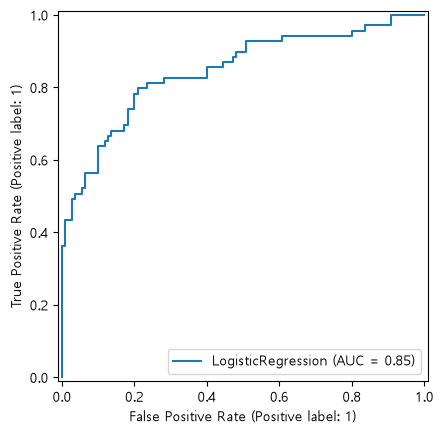

In [57]:
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

In [59]:
#각 가중치
# lr.coef_[0]

coef_df = pd.DataFrame({
    "Features" : X_train.columns,
    "Coef" : lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
1,Sex,1.334007
3,Fare,0.153159
4,FamilySize,-0.314203
2,Age,-0.506069
0,Pclass,-0.910758


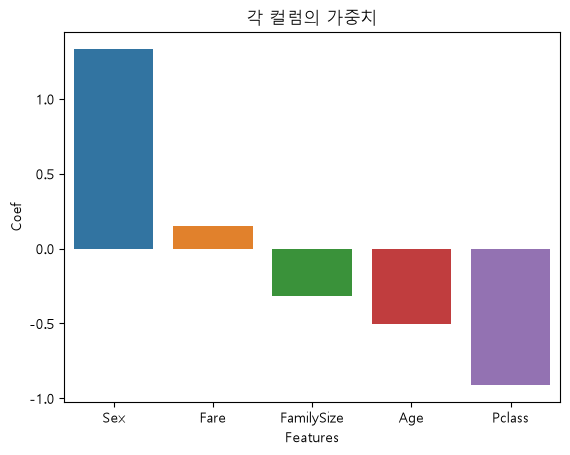

In [61]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features")
plt.title("각 컬럼의 가중치")
plt.show()

"""
    성별은 양의 상관관계를 가진다. 즉 성별이 1(female)일수록 생존 확률이 높다(1).
    객실 등급(Pclass)는 음의 상관관계를 가진다. 즉 객실 등급이 낮을수록()
"""
None

In [62]:
# 모델이 틀리게 예측한 행
wrong_cases = X_test[y_test != y_pred]
wrong_cases.head()

,Pclass,Sex,Age,Fare,FamilySize
400,3,0,39,7.9250,1
593,3,1,28,7.7500,3
630,1,0,80,30.0000,1
569,3,0,32,7.8542,1
271,3,0,25,0.0000,1


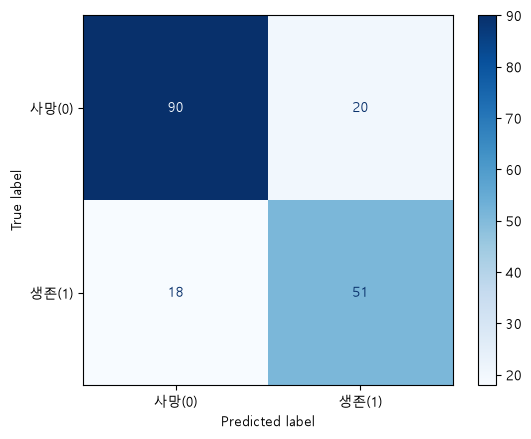

In [64]:
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test,
    display_labels=["사망(0)", "생존(1)"],
    cmap="Blues"
)

plt.title("타이타닉 로지스틱 회귀 혼동행렬")
plt.show()

In [65]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       108
           1       0.74      0.72      0.73        71

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

